# Phase 1 — Time Series Fundamentals
## Lesson 2 — Time Index, Frequency, and Sampling

### Learning Objectives

By the end of this lesson, you should be able to:

- Understand what a **time index** is
- Recognize the **frequency** of time-series data
- Create dates using `pd.date_range()`
- Understand **regular vs irregular** time series
- Use `asfreq()` to enforce a frequency
- Understand **downsampling** and **upsampling**
- Use `resample()` to convert data from one frequency to another
- Visualize data before and after resampling

## 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. Review from Lesson 1

We begin with a simple monthly time series.

In [2]:
data = {
    "Date": [
        "2026-01-01",
        "2026-02-01",
        "2026-03-01",
        "2026-04-01",
        "2026-05-01",
        "2026-06-01"
    ],
    "Visitors": [
        1200,
        1350,
        1280,
        1500,
        1750,
        1900
    ]
}

df = pd.DataFrame(data)

df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date")

df

,Visitors
Date,
2026-01-01,1200
2026-02-01,1350
2026-03-01,1280
2026-04-01,1500
2026-05-01,1750
2026-06-01,1900


## 3. What is a Time Index?

A **time index** means that dates or timestamps are used as the DataFrame index.

This allows Pandas to understand that the observations are ordered through time.

In [3]:
df.index

DatetimeIndex(['2026-01-01', '2026-02-01', '2026-03-01', '2026-04-01',
               '2026-05-01', '2026-06-01'],
              dtype='datetime64[ns]', name='Date', freq=None)

In [4]:
type(df.index)

pandas.core.indexes.datetimes.DatetimeIndex

### Selecting observations using dates

In [5]:
df.loc["2026-03-01"]

Visitors    1280
Name: 2026-03-01 00:00:00, dtype: int64

In [6]:
df.loc["2026-02-01":"2026-05-01"]

,Visitors
Date,
2026-02-01,1350
2026-03-01,1280
2026-04-01,1500
2026-05-01,1750


In [7]:
df.loc["2026"]

,Visitors
Date,
2026-01-01,1200
2026-02-01,1350
2026-03-01,1280
2026-04-01,1500
2026-05-01,1750
2026-06-01,1900


## Exercise 1

Using `df`:

1. Display only April 2026.
2. Display February through May.
3. Display all observations from 2026.
4. Check the type of `df.index`.

In [8]:
# Write your answers here
df.loc["2026-04-01"]

Visitors    1500
Name: 2026-04-01 00:00:00, dtype: int64

## 4. What is Time-Series Frequency?

**Frequency** tells us how often observations occur.

Examples:

| Data | Frequency |
|---|---|
| Forex tick data | Milliseconds / Seconds |
| Forex candles | Minutes / Hours |
| Daily stock prices | Daily |
| Website traffic | Weekly |
| Revenue | Monthly |
| GDP | Quarterly |
| Population | Yearly |

For our visitor dataset, the observations occur once every month.

## 5. Checking Frequency in Pandas

In [9]:
df.index.freq
print(df.index.freq)

None


Pandas may return `None` because the dates exist, but the frequency has not been explicitly assigned.

We can ask Pandas to infer the frequency.

In [10]:
pd.infer_freq(df.index)

'MS'

`MS` means **Month Start**.

## 6. Common Pandas Frequency Codes

| Code | Meaning |
|---|---|
| `D` | Day |
| `h` | Hour |
| `min` | Minute |
| `s` | Second |
| `W` | Week |
| `MS` | Month Start |
| `ME` | Month End |
| `QS` | Quarter Start |
| `YS` | Year Start |

## 7. Creating Dates with `pd.date_range()`

In [11]:
dates = pd.date_range(
    start="2026-01-01",
    periods=6,
    freq="MS"
)

dates

DatetimeIndex(['2026-01-01', '2026-02-01', '2026-03-01', '2026-04-01',
               '2026-05-01', '2026-06-01'],
              dtype='datetime64[ns]', freq='MS')

### Create a time series more efficiently

In [12]:
visitors = [
    1200,
    1350,
    1280,
    1500,
    1750,
    1900
]

df2 = pd.DataFrame({
    "Visitors": visitors
}, index=dates)

df2

,Visitors
2026-01-01,1200
2026-02-01,1350
2026-03-01,1280
2026-04-01,1500
2026-05-01,1750
2026-06-01,1900


## Exercise 2

Create 10 daily dates beginning on `2026-07-01`.

Use these sales values:

```python
sales = [
    100,
    120,
    115,
    140,
    150,
    145,
    170,
    180,
    175,
    200
]
```

Create a DataFrame called `sales_df` with the dates as its index.

In [13]:
dates_days = pd.date_range(
    start="2026-07-01",
    periods=10,
    freq="D"
)

dates_days

DatetimeIndex(['2026-07-01', '2026-07-02', '2026-07-03', '2026-07-04',
               '2026-07-05', '2026-07-06', '2026-07-07', '2026-07-08',
               '2026-07-09', '2026-07-10'],
              dtype='datetime64[ns]', freq='D')

In [14]:
# Write your solution here

sales = [
    100,
    120,
    115,
    140,
    150,
    145,
    170,
    180,
    175,
    200
]
sales_df =  pd.DataFrame({
    "sales": sales
}, index=dates_days)

sales_df

,sales
2026-07-01,100
2026-07-02,120
2026-07-03,115
2026-07-04,140
2026-07-05,150
2026-07-06,145
2026-07-07,170
2026-07-08,180
2026-07-09,175
2026-07-10,200


## 8. Visualizing a Daily Time Series

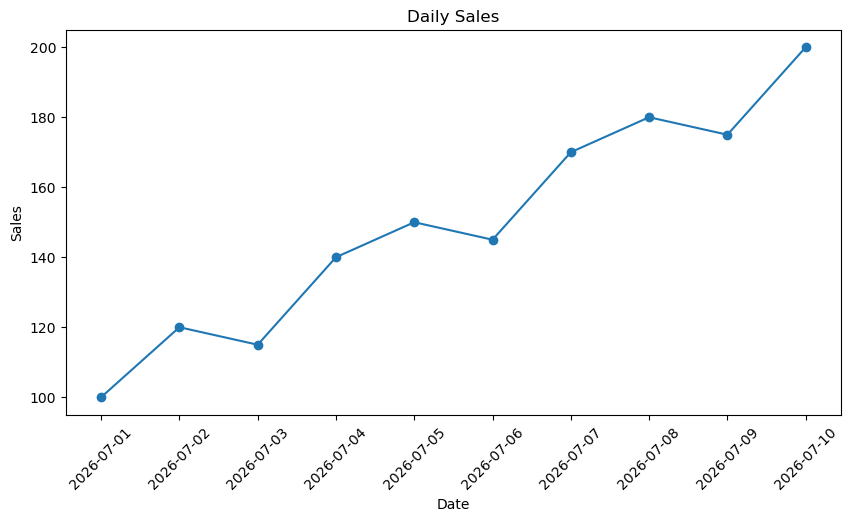

In [15]:
dates = pd.date_range(
    start="2026-07-01",
    periods=10,
    freq="D"
)

sales = [
    100, 120, 115, 140, 150,
    145, 170, 180, 175, 200
]

sales_df = pd.DataFrame({
    "Sales": sales
}, index=dates)

plt.figure(figsize=(10, 5))

plt.plot(
    sales_df.index,
    sales_df["Sales"],
    marker="o"
)

plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Daily Sales")
plt.xticks(rotation=45)

plt.show()

## 9. Regular vs Irregular Time Series

### Regular time series

Observations occur at equal time intervals.

Example:

- Jan 1
- Jan 2
- Jan 3
- Jan 4
- Jan 5

### Irregular time series

Observations do not occur at equal intervals.

Example:

- Jan 1
- Jan 2
- Jan 5
- Jan 9
- Jan 10

In [16]:
dates = pd.to_datetime([
    "2026-01-01",
    "2026-01-02",
    "2026-01-05",
    "2026-01-09",
    "2026-01-10"
])

values = [100, 105, 110, 120, 125]

irregular_df = pd.DataFrame({
    "Value": values
}, index=dates)

irregular_df

,Value
2026-01-01,100
2026-01-02,105
2026-01-05,110
2026-01-09,120
2026-01-10,125


In [17]:
pd.infer_freq(irregular_df.index)

### Visualize the irregular series

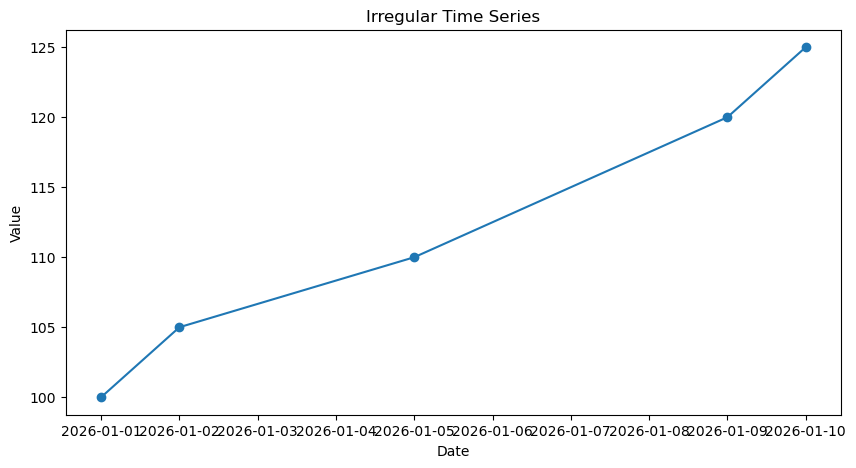

In [18]:
plt.figure(figsize=(10, 5))

plt.plot(
    irregular_df.index,
    irregular_df["Value"],
    marker="o"
)

plt.xlabel("Date")
plt.ylabel("Value")
plt.title("Irregular Time Series")

plt.show()

## 10. Setting Frequency with `asfreq()`

If the data should be daily, we can explicitly enforce a daily frequency.

In [19]:
regular_df = irregular_df.asfreq("D")

regular_df

,Value
2026-01-01,100.0
2026-01-02,105.0
2026-01-03,NaN
2026-01-04,NaN
2026-01-05,110.0
2026-01-06,NaN
2026-01-07,NaN
2026-01-08,NaN
2026-01-09,120.0
2026-01-10,125.0


Missing dates now appear with `NaN`.

This is useful for detecting gaps in a time series.

## Exercise 3

Create:

```python
dates = pd.to_datetime([
    "2026-08-01",
    "2026-08-02",
    "2026-08-04",
    "2026-08-07"
])

temperature = [
    34,
    35,
    37,
    38
]
```

Then:

1. Create a DataFrame.
2. Check its frequency with `pd.infer_freq()`.
3. Convert it to daily frequency using `asfreq("D")`.
4. Identify the missing dates.

In [51]:
# Write your solution here
dates = pd.to_datetime([
    "2026-08-01",
    "2026-08-02",
    "2026-08-04",
    "2026-08-07"
])

temperature = [
    34,
    35,
    37,
    38
]

df = pd.DataFrame({
    "Temperatures": temperature
}, index=dates)


df

,Temperatures
2026-08-01,34
2026-08-02,35
2026-08-04,37
2026-08-07,38


In [52]:
print(df.index.freq)

None


In [53]:
df.asfreq("D")

,Temperatures
2026-08-01,34.0
2026-08-02,35.0
2026-08-03,NaN
2026-08-04,37.0
2026-08-05,NaN
2026-08-06,NaN
2026-08-07,38.0


## 11. What is Resampling?

**Resampling** means changing the time frequency of a dataset.

### Downsampling

Higher frequency → Lower frequency

Examples:

- Daily → Weekly
- Daily → Monthly
- Hourly → Daily
- 5-minute → Hourly

### Upsampling

Lower frequency → Higher frequency

Examples:

- Monthly → Daily
- Daily → Hourly
- Hourly → 15-minute

## 12. Downsampling Example — Daily to Weekly

In [21]:
dates = pd.date_range(
    start="2026-01-01",
    periods=14,
    freq="D"
)

sales = [
    100, 120, 130, 110, 140, 160, 150,
    170, 180, 160, 190, 200, 210, 220
]

sales_df = pd.DataFrame({
    "Sales": sales
}, index=dates)

sales_df

,Sales
2026-01-01,100
2026-01-02,120
2026-01-03,130
2026-01-04,110
2026-01-05,140
2026-01-06,160
2026-01-07,150
2026-01-08,170
2026-01-09,180
2026-01-10,160


In [22]:
weekly_sales = sales_df.resample("W").sum()

weekly_sales

,Sales
2026-01-04,460
2026-01-11,1150
2026-01-18,630


## 13. Choosing the Correct Aggregation

Different variables require different aggregation functions.

Common choices:

| Function | Meaning |
|---|---|
| `.sum()` | Total |
| `.mean()` | Average |
| `.min()` | Minimum |
| `.max()` | Maximum |
| `.median()` | Median |
| `.count()` | Number of observations |

Example:

- Weekly sales → often `.sum()`
- Weekly temperature → often `.mean()`

In [23]:
sales_df.resample("W").mean()

,Sales
2026-01-04,115.000000
2026-01-11,164.285714
2026-01-18,210.000000


In [24]:
sales_df.resample("W").max()

,Sales
2026-01-04,130
2026-01-11,190
2026-01-18,220


In [25]:
sales_df.resample("W").min()

,Sales
2026-01-04,100
2026-01-11,140
2026-01-18,200


## 14. Compare Daily and Weekly Data Visually

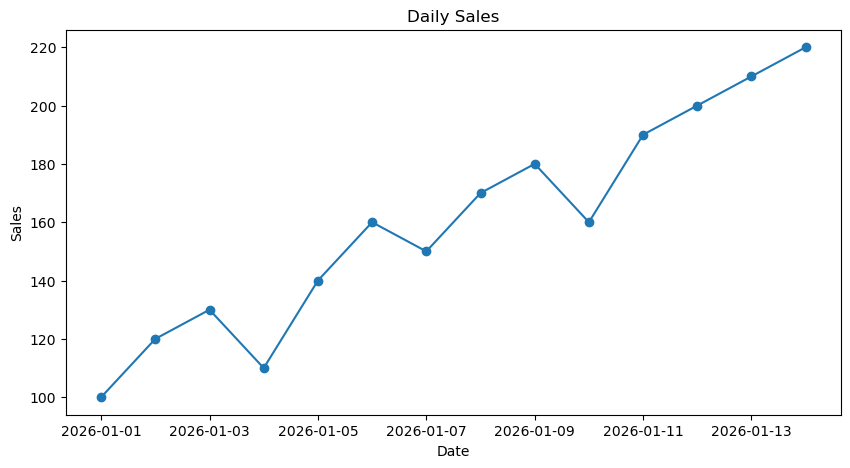

In [26]:
plt.figure(figsize=(10, 5))

plt.plot(
    sales_df.index,
    sales_df["Sales"],
    marker="o"
)

plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Daily Sales")

plt.show()

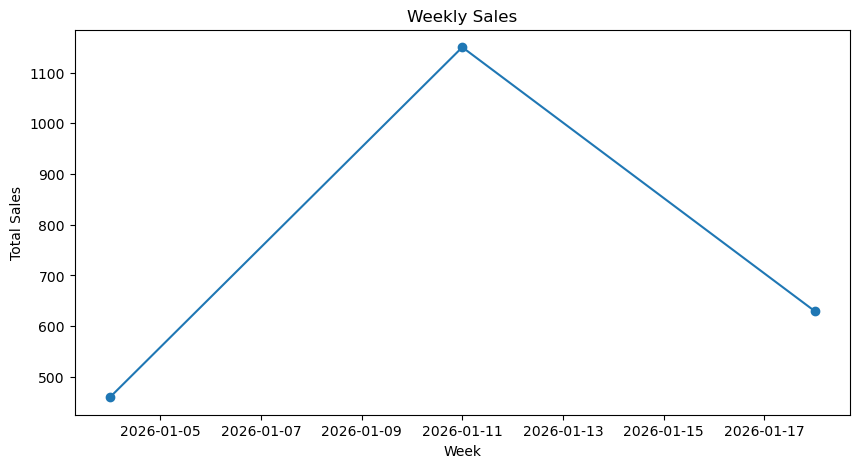

In [27]:
plt.figure(figsize=(10, 5))

plt.plot(
    weekly_sales.index,
    weekly_sales["Sales"],
    marker="o"
)

plt.xlabel("Week")
plt.ylabel("Total Sales")
plt.title("Weekly Sales")

plt.show()

## 15. `asfreq()` vs `resample()`

### `asfreq()`

Used mainly to organize data onto a specific frequency.

Example:

```python
df.asfreq("D")
```

It can reveal missing periods.

### `resample()`

Used to regroup observations into time periods and calculate something.

Example:

```python
df.resample("W").sum()
```

Think:

- `asfreq()` → organize the timeline
- `resample()` → regroup and aggregate

## 16. Forex Connection

If you later work with Forex data, you may have:

- 1-minute candles
- 5-minute candles
- Hourly candles
- Daily candles

Changing from 1-minute data to hourly data is **downsampling**.

Financial OHLC data usually uses:

- Open → first value
- High → maximum value
- Low → minimum value
- Close → last value

We will handle OHLC resampling in a later lesson.

## 17. Mini Example — Website Visitors

In [28]:
dates = pd.date_range(
    start="2026-01-01",
    periods=30,
    freq="D"
)

visitors = [
    100, 105, 110, 108, 115,
    120, 125, 130, 128, 135,
    140, 145, 150, 148, 155,
    160, 165, 170, 168, 175,
    180, 185, 190, 188, 195,
    200, 205, 210, 208, 215
]

website = pd.DataFrame({
    "Visitors": visitors
}, index=dates)

website.head()

,Visitors
2026-01-01,100
2026-01-02,105
2026-01-03,110
2026-01-04,108
2026-01-05,115


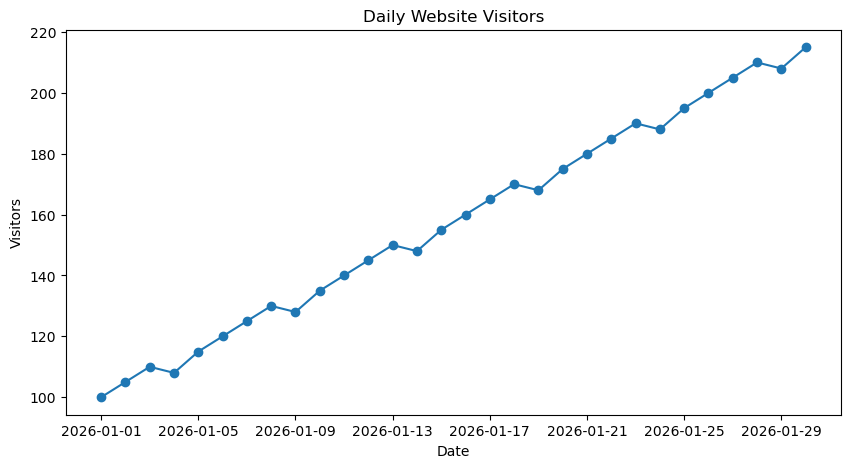

In [29]:
plt.figure(figsize=(10, 5))

plt.plot(
    website.index,
    website["Visitors"],
    marker="o"
)

plt.xlabel("Date")
plt.ylabel("Visitors")
plt.title("Daily Website Visitors")

plt.show()

In [30]:
weekly = website.resample("W").mean()

weekly

,Visitors
2026-01-04,105.750000
2026-01-11,127.571429
2026-01-18,156.142857
2026-01-25,183.000000
2026-02-01,207.600000


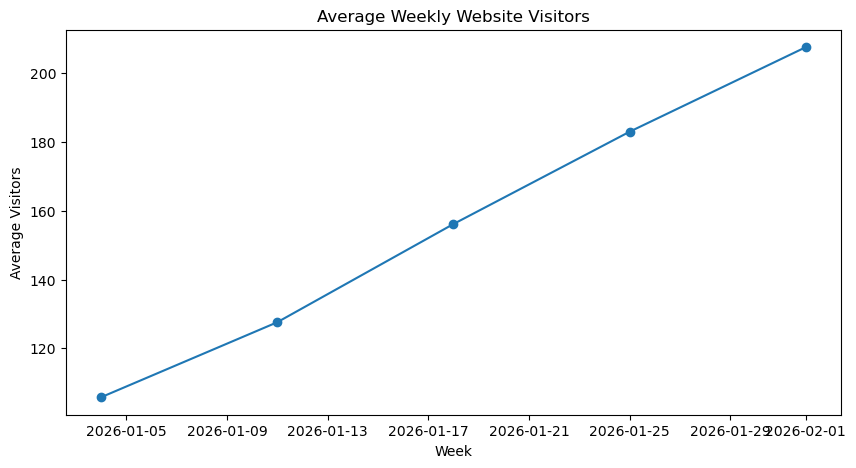

In [31]:
plt.figure(figsize=(10, 5))

plt.plot(
    weekly.index,
    weekly["Visitors"],
    marker="o"
)

plt.xlabel("Week")
plt.ylabel("Average Visitors")
plt.title("Average Weekly Website Visitors")

plt.show()

## 18. Extracting Information from the Time Index

In [32]:
website.index.year

Index([2026, 2026, 2026, 2026, 2026, 2026, 2026, 2026, 2026, 2026, 2026, 2026,
       2026, 2026, 2026, 2026, 2026, 2026, 2026, 2026, 2026, 2026, 2026, 2026,
       2026, 2026, 2026, 2026, 2026, 2026],
      dtype='int32')

In [33]:
website.index.month

Index([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1],
      dtype='int32')

In [34]:
website.index.day

Index([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30],
      dtype='int32')

In [35]:
website.index.day_name()

Index(['Thursday', 'Friday', 'Saturday', 'Sunday', 'Monday', 'Tuesday',
       'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday', 'Monday',
       'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday',
       'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday',
       'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'],
      dtype='object')

In [36]:
website["Day"] = website.index.day
website["DayName"] = website.index.day_name()

website.head()

,Visitors,Day,DayName
2026-01-01,100,1,Thursday
2026-01-02,105,2,Friday
2026-01-03,110,3,Saturday
2026-01-04,108,4,Sunday
2026-01-05,115,5,Monday


## Exercise 4 — Resampling

Using the `website` dataset:

1. Calculate weekly total visitors.
2. Calculate weekly average visitors.
3. Calculate weekly maximum visitors.

Then explain why the three results are different.

In [69]:
# Write your solution here
website_weekly = website[['Visitors']].resample('W').sum()
website_weekly

,Visitors
2026-01-04,423
2026-01-11,893
2026-01-18,1093
2026-01-25,1281
2026-02-01,1038


In [74]:
website_mean = website[['Visitors']].resample('W').mean()
website_mean

,Visitors
2026-01-04,105.750000
2026-01-11,127.571429
2026-01-18,156.142857
2026-01-25,183.000000
2026-02-01,207.600000


In [75]:
website_max = website[['Visitors']].resample('W').max()
website_max

,Visitors
2026-01-04,110
2026-01-11,140
2026-01-18,170
2026-01-25,195
2026-02-01,215


## Exercise 5 — Visualization

Create two plots:

### Plot 1
Daily website visitors.

### Plot 2
Weekly average website visitors.

Then write one sentence explaining which graph looks smoother and why.

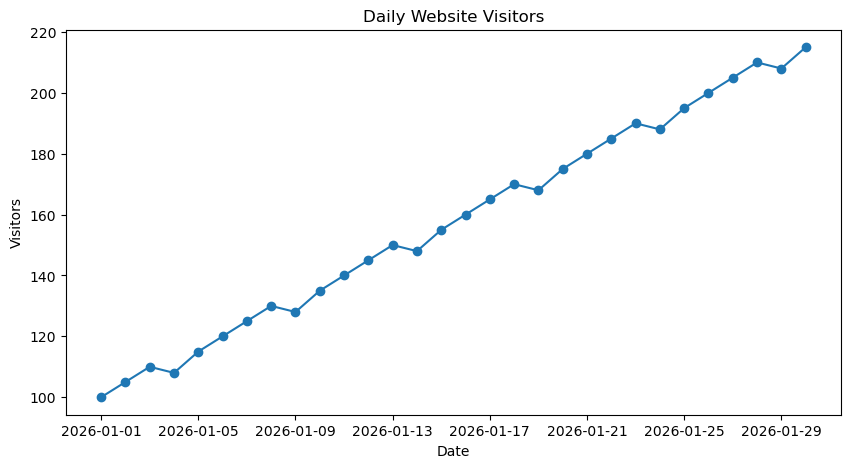

In [72]:
# Plot 1 : Daily website visitor
plt.figure(figsize=(10, 5))

plt.plot(
    website.index,
    website["Visitors"],
    marker="o"
)

plt.xlabel("Date")
plt.ylabel("Visitors")
plt.title("Daily Website Visitors")

plt.show()

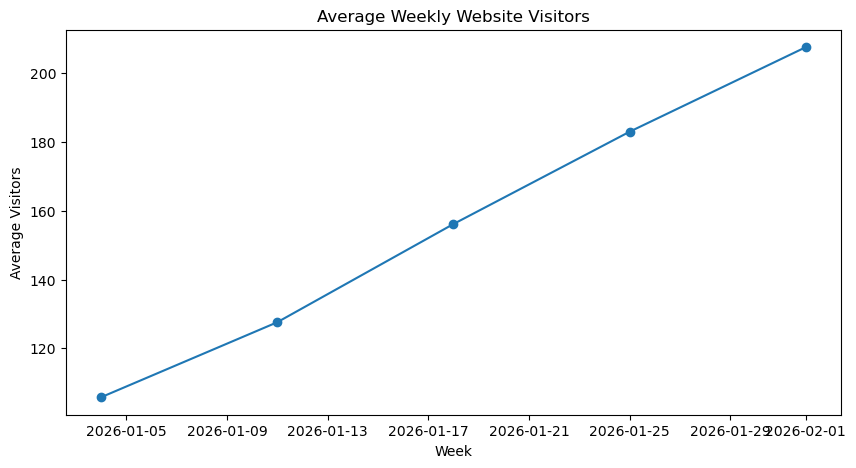

In [73]:
# Write your plots here
# Plot 2 : Weelly website visitors
plt.figure(figsize=(10, 5))

plt.plot(
    weekly.index,
    weekly["Visitors"],
    marker="o"
)

plt.xlabel("Week")
plt.ylabel("Average Visitors")
plt.title("Average Weekly Website Visitors")

plt.show()

## 19. Quick Knowledge Check

### Question 1
What is a `DatetimeIndex`?

A. A list of prices  
B. Dates used as the DataFrame index  
C. A forecasting model  
D. A graph

### Question 2
What is the frequency here?

- 2026-01-01
- 2026-02-01
- 2026-03-01
- 2026-04-01

A. Daily  
B. Weekly  
C. Monthly  
D. Hourly

### Question 3
What does this create?

```python
pd.date_range(
    start="2026-01-01",
    periods=10,
    freq="D"
)
```

### Question 4
Daily → Monthly is:

A. Upsampling  
B. Downsampling

### Question 5
Which would you normally use to calculate total weekly sales?

```python
.resample("W").sum()
```

or

```python
.resample("W").mean()
```

Explain why.

### Question 6
What is the difference between `asfreq()` and `resample()`?

# Final Practice Task — Store Sales

Complete this section without looking back at the examples.

You have the following daily sales:

In [79]:
sales = [
    120, 135, 128, 145, 150,
    160, 155, 170, 180, 175,
    190, 200, 195, 210,
    220, 215, 230, 240,
    235, 250, 260
]

## Step 1 — Create Dates

Create daily dates beginning on:

`2026-03-01`

Use `pd.date_range()`.

In [91]:
# Your solution
dates = pd.date_range(    
    start="2026-03-01",
    periods=21,
    freq="D"
    )
dates

DatetimeIndex(['2026-03-01', '2026-03-02', '2026-03-03', '2026-03-04',
               '2026-03-05', '2026-03-06', '2026-03-07', '2026-03-08',
               '2026-03-09', '2026-03-10', '2026-03-11', '2026-03-12',
               '2026-03-13', '2026-03-14', '2026-03-15', '2026-03-16',
               '2026-03-17', '2026-03-18', '2026-03-19', '2026-03-20',
               '2026-03-21'],
              dtype='datetime64[ns]', freq='D')

## Step 2 — Create the DataFrame

Create `sales_df` with:

- Date → index
- Sales → column

In [100]:
# Your solution
sales_df =  pd.DataFrame({
    "sales": sales
}, index=dates)

df_Sales.head()

,sales
2026-03-01,120
2026-03-02,135
2026-03-03,128
2026-03-04,145
2026-03-05,150


## Step 3 — Inspect the Time Index

Display `sales_df.index` and check its type.

In [101]:
# Your solution
sales_df.index

DatetimeIndex(['2026-03-01', '2026-03-02', '2026-03-03', '2026-03-04',
               '2026-03-05', '2026-03-06', '2026-03-07', '2026-03-08',
               '2026-03-09', '2026-03-10', '2026-03-11', '2026-03-12',
               '2026-03-13', '2026-03-14', '2026-03-15', '2026-03-16',
               '2026-03-17', '2026-03-18', '2026-03-19', '2026-03-20',
               '2026-03-21'],
              dtype='datetime64[ns]', freq='D')

## Step 4 — Find the Frequency

Use `pd.infer_freq()`.

In [102]:
# Your solution
pd.infer_freq(sales_df.index)

'D'

## Step 5 — Select a Date Range

Display sales between:

- `2026-03-05`
- `2026-03-12`

In [105]:
# Your solution
print(sales_df.loc["2026-03-05":"2026-03-12"])



            sales
2026-03-05    150
2026-03-06    160
2026-03-07    155
2026-03-08    170
2026-03-09    180
2026-03-10    175
2026-03-11    190
2026-03-12    200


In [108]:
sales_df[
    (sales_df.index >= pd.to_datetime("2026-01-01")) &
    (sales_df.index <= pd.to_datetime("2026-03-31"))
]

,sales
2026-03-01,120
2026-03-02,135
2026-03-03,128
2026-03-04,145
2026-03-05,150
2026-03-06,160
2026-03-07,155
2026-03-08,170
2026-03-09,180
2026-03-10,175


## Step 6 — Resample

Calculate:

- Weekly total sales → `weekly_total`
- Weekly average sales → `weekly_average`

In [45]:
# Your solution

## Step 7 — Plot Daily Sales

Requirements:

- `figsize=(10, 5)`
- `marker="o"`
- X-axis label
- Y-axis label
- Title

In [46]:
# Your solution

## Step 8 — Plot Weekly Average Sales

Use the title:

`Weekly Average Sales`

In [47]:
# Your solution

## Step 9 — Interpretation

Write 2–3 sentences answering:

1. What is the frequency of the original dataset?
2. What happened to the number of observations after weekly resampling?
3. Why does the weekly average graph look different from the daily graph?

### Your Answer

Write your interpretation here.

# Lesson 2 Summary

The most important tools from this lesson are:

```python
pd.to_datetime()
pd.date_range()
pd.infer_freq()
df.asfreq()
df.resample()
```

### Key Idea

> Always know the frequency of your data before analyzing or forecasting a time series.

### Next Lesson

**Lesson 3 — Time Series Visualization**